In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_news = pd.read_csv('../data/raw/news_data.csv')
df_news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [6]:
df_aapl = pd.read_csv('../data/raw/AAPL.csv')
df_aapl.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [7]:
print(df_news.shape)
print(df_news.columns)
print(df_news.info())

(1407328, 6)
Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB
None


In [8]:
df_news.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [9]:
df_news['headline_length'] = df_news['headline'].str.len()
df_news['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

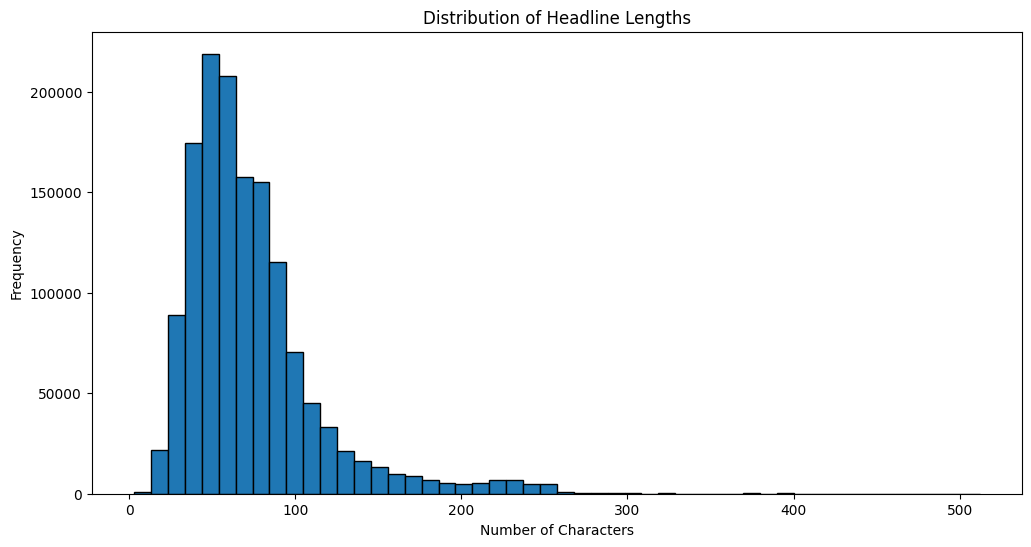

In [10]:
plt.figure(figsize=(12, 6))
plt.hist(df_news['headline_length'], bins=50, edgecolor='black')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

In [11]:
top_publishers = df_news['publisher'].value_counts().head(10)
print(top_publishers)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


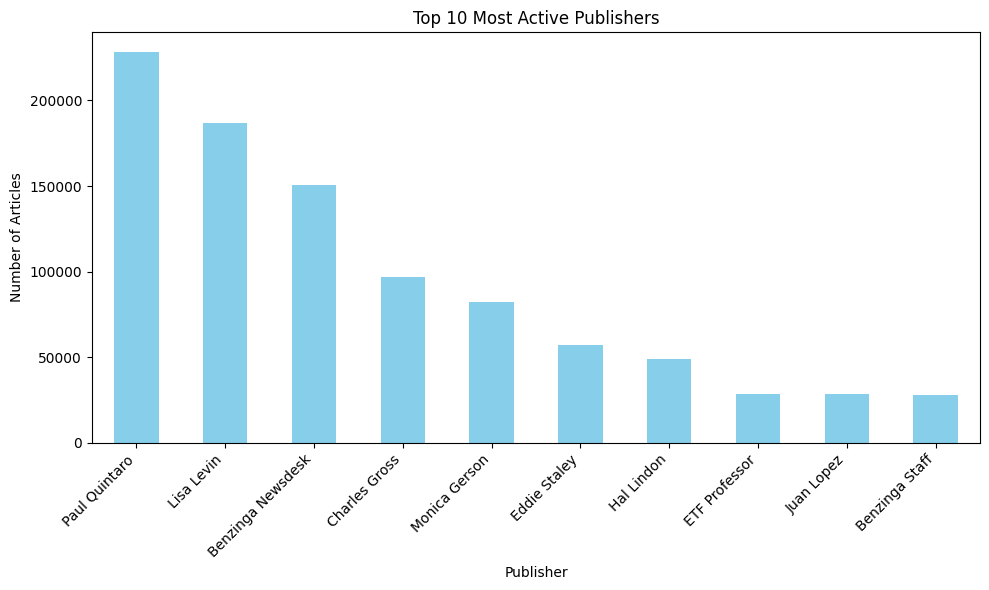

In [12]:
plt.figure(figsize=(10, 6))
top_publishers.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce')
df_news['year'] = df_news['date'].dt.year
df_news['month'] = df_news['date'].dt.month
df_news['hour'] = df_news['date'].dt.hour

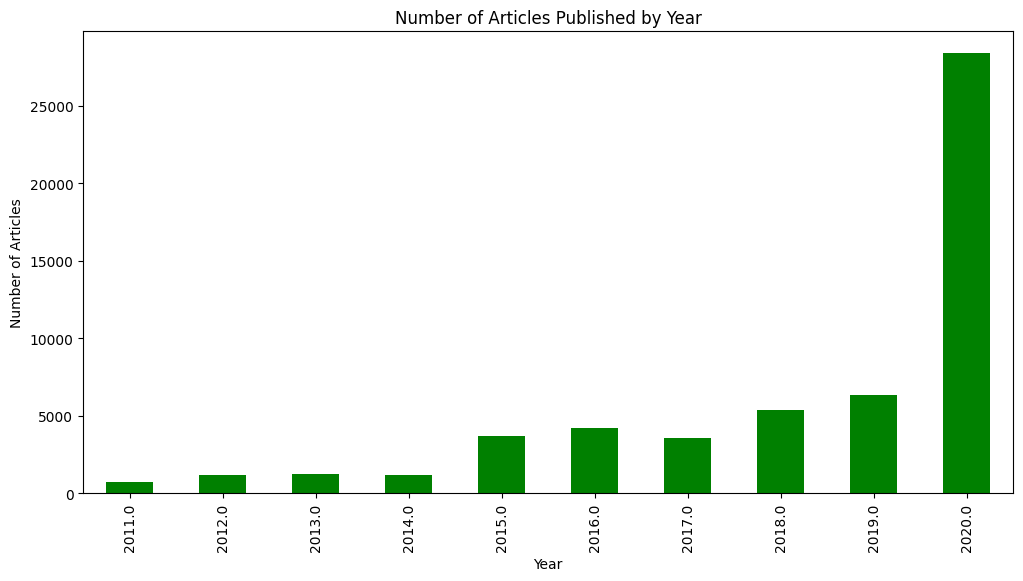

In [14]:
articles_by_year = df_news['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
articles_by_year.plot(kind='bar', color='green')
plt.title('Number of Articles Published by Year')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.show()

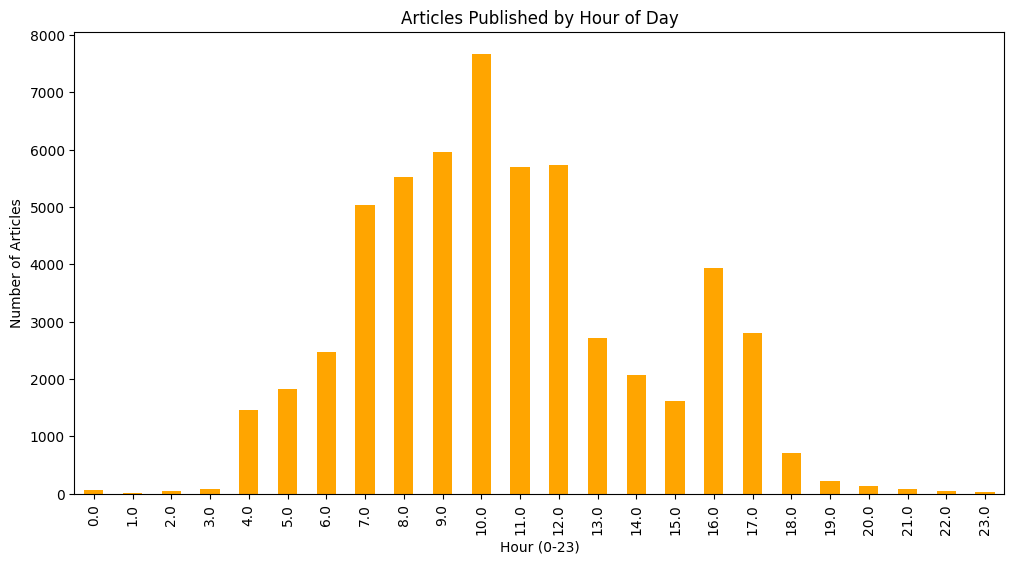

In [15]:
articles_by_hour = df_news['hour'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
articles_by_hour.plot(kind='bar', color='orange')
plt.title('Articles Published by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Articles')
plt.show()

In [16]:
top_stocks = df_news['stock'].value_counts().head(10)
print(top_stocks)

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64


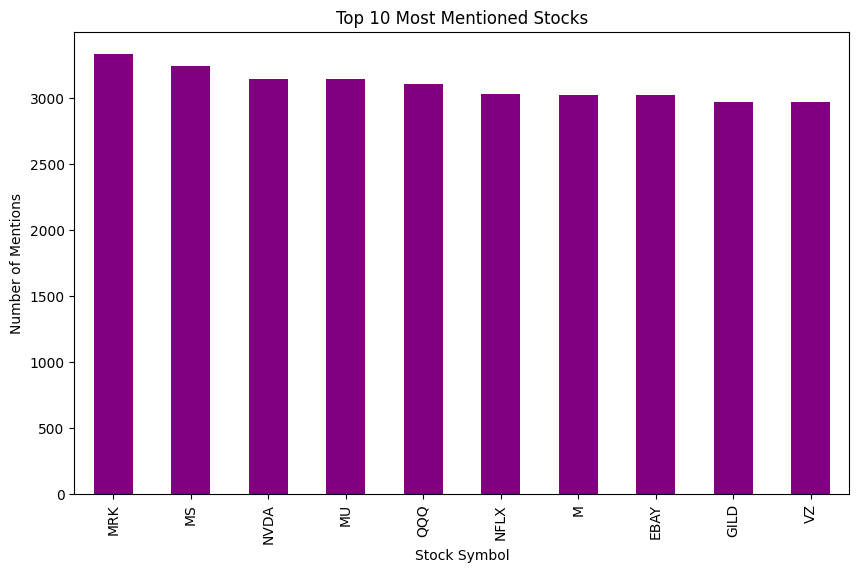

In [17]:
plt.figure(figsize=(10, 6))
top_stocks.plot(kind='bar', color='purple')
plt.title('Top 10 Most Mentioned Stocks')
plt.xlabel('Stock Symbol')
plt.ylabel('Number of Mentions')
plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample 10k headlines for speed
sample_headlines = df_news['headline'].dropna().sample(10000, random_state=42)

vectorizer = CountVectorizer(max_features=20, stop_words='english')
X = vectorizer.fit_transform(sample_headlines)
words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

word_freq = pd.DataFrame({'word': words, 'count': counts}).sort_values('count', ascending=False)
print(word_freq)

         word  count
18         vs   1217
14     stocks   1197
6         est   1059
5         eps    945
7      market    897
13     shares    827
11    reports    776
16     update    680
4    earnings    618
12      sales    578
10         pt    525
2    benzinga    518
8         mid    500
1   announces    493
19       week    492
9       price    484
3         buy    465
15    trading    441
17   upgrades    429
0          52    422
